# Systolic Blood Pressure Predictor

**Mission:** Predict systolic blood pressure (mmHg) from demographic and clinical health indicators.  
Hypertension affects 1 in 3 adults and is the leading preventable cause of heart disease and stroke.  
Early prediction from routine health measurements enables timely lifestyle intervention before clinical diagnosis.

**Dataset:** CDC NHANES (National Health and Nutrition Examination Survey) 2013-2014  
**Source:** https://www.kaggle.com/datasets/cdc/national-health-and-nutrition-examination-survey  
**Origin:** CDC National Center for Health Statistics — real clinical measurements from 10,175 US civilians  
**Files used:** demographic.csv + examination.csv (merged on SEQN participant ID)

**Target Variable:** `BPXSY1` — First Systolic Blood Pressure reading (mmHg), continuous numeric

**Features:** Age, Gender, Race/Ethnicity, Income-to-Poverty Ratio, Diastolic BP, Pulse Rate, BMI, Waist Circumference

In [88]:
# Step 1: Import Libraries

# Imports
import os, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings("ignore")

print('All libraries imported successfully!')

All libraries imported successfully!


In [89]:
# Step 2: Load and Merge the Dataset

# I merged two files (demographic.csv and examination.csv)  on SEQN, a unique participant ID shared across all NHANES files

demo = pd.read_csv('demographic.csv')
exam = pd.read_csv('examination.csv')

print(f'demographic.csv shape: {demo.shape}')
print(f'examination.csv shape: {exam.shape}')


# Select only the columns needed from each file before merging to reduce memory and keep the dataset clean

demo_cols = ['SEQN', 'RIAGENDR', 'RIDAGEYR', 'RIDRETH3', 'INDFMPIR']
exam_cols = ['SEQN', 'BPXSY1', 'BPXDI1', 'BPXPLS', 'BMXBMI', 'BMXWAIST']

df = pd.merge(demo[demo_cols], exam[exam_cols], on='SEQN')
df = df.drop(columns=['SEQN'])

# Rename columns for clarity

df.columns = ['Gender', 'Age', 'Race', 'Income_Poverty_Ratio',
              'Systolic_BP', 'Diastolic_BP', 'Pulse_Rate', 'BMI', 'Waist_cm']

print(f'\nMerged dataset shape: {df.shape}')
print(f'\nFirst 5 rows:')
df.head()

demographic.csv shape: (10175, 47)
examination.csv shape: (9813, 224)

Merged dataset shape: (9813, 9)

First 5 rows:


,Gender,Age,Race,Income_Poverty_Ratio,Systolic_BP,Diastolic_BP,Pulse_Rate,BMI,Waist_cm
0,1,69,4,0.84,122.0,72.0,86.0,26.7,100.0
1,1,54,3,1.78,156.0,62.0,74.0,28.6,107.6
2,1,72,3,4.51,140.0,90.0,68.0,28.9,109.2
3,1,9,3,2.52,108.0,38.0,64.0,17.1,61.0
4,2,73,3,5.00,136.0,86.0,92.0,19.7,NaN


In [90]:
# Step 3: Explore the Data

print('=== Basic Statistics ===')
print(df.describe().round(2))

print('\n=== Data Types ===')
print(df.dtypes)

print('\n=== Missing Values ===')
missing = df.isnull().sum()
pct = (missing / len(df) * 100).round(1)
miss_df = pd.DataFrame({'Missing Count': missing, 'Missing %': pct})
print(miss_df)

print(f'\n=== Target Variable: Systolic Blood Pressure ===')
print(df['Systolic_BP'].describe())
print(f'\nNormal:       < 120 mmHg')
print(f'Elevated:     120-129 mmHg')
print(f'High Stage 1: 130-139 mmHg')
print(f'High Stage 2: >= 140 mmHg')

=== Basic Statistics ===
        Gender      Age     Race  Income_Poverty_Ratio  Systolic_BP  \
count  9813.00  9813.00  9813.00               9083.00      7172.00   
mean      1.51    31.63     3.28                  2.25       118.12   
std       0.50    24.40     1.61                  1.63        18.08   
min       1.00     0.00     1.00                  0.00        66.00   
25%       1.00    10.00     2.00                  0.88       106.00   
50%       2.00    27.00     3.00                  1.70       116.00   
75%       2.00    52.00     4.00                  3.58       128.00   
max       2.00    80.00     7.00                  5.00       228.00   

       Diastolic_BP  Pulse_Rate      BMI  Waist_cm  
count       7172.00     7549.00  9055.00   8661.00  
mean          65.77       74.42    25.68     87.27  
std           14.96       12.37     7.96     22.54  
min            0.00       40.00    12.10     40.20  
25%           58.00       66.00    19.70     71.20  
50%           66.

### **Feature Engineering Key decisions:**
1. Drop rows where TARGET (Systolic_BP) is missing as we cannot impute a target variable
2. All columns are already numeric (NHANES encodes everything as numbers)
   - Gender: 1=Male, 2=Female | Race: 1-7 category codes, no additional encoding needed
3. Fill remaining feature missing values with column median (robust to clinical outliers)
4. Keep all 8 features and correlation, heatmap will reveal which carry the most weight

In [91]:
# Step 4: Feature Engineering

TARGET = 'Systolic_BP'

# Drop rows where target is missing
df = df.dropna(subset=[TARGET])
print(f'Rows after dropping missing target: {len(df):,}')

# Separate features and target
y = df[TARGET].copy()
X = df.drop(columns=[TARGET]).copy()


print(f'\nFeatures ({len(X.columns)}): {X.columns.tolist()}')

# Fill remaining missing values with column median
X = X.fillna(X.median())

print(f'Missing values remaining: {X.isnull().sum().sum()}')
print(f'\nTarget range: {y.min():.0f} — {y.max():.0f} mmHg')
print(f'Target mean:  {y.mean():.1f} mmHg')

Rows after dropping missing target: 7,172

Features (8): ['Gender', 'Age', 'Race', 'Income_Poverty_Ratio', 'Diastolic_BP', 'Pulse_Rate', 'BMI', 'Waist_cm']
Missing values remaining: 0

Target range: 66 — 228 mmHg
Target mean:  118.1 mmHg


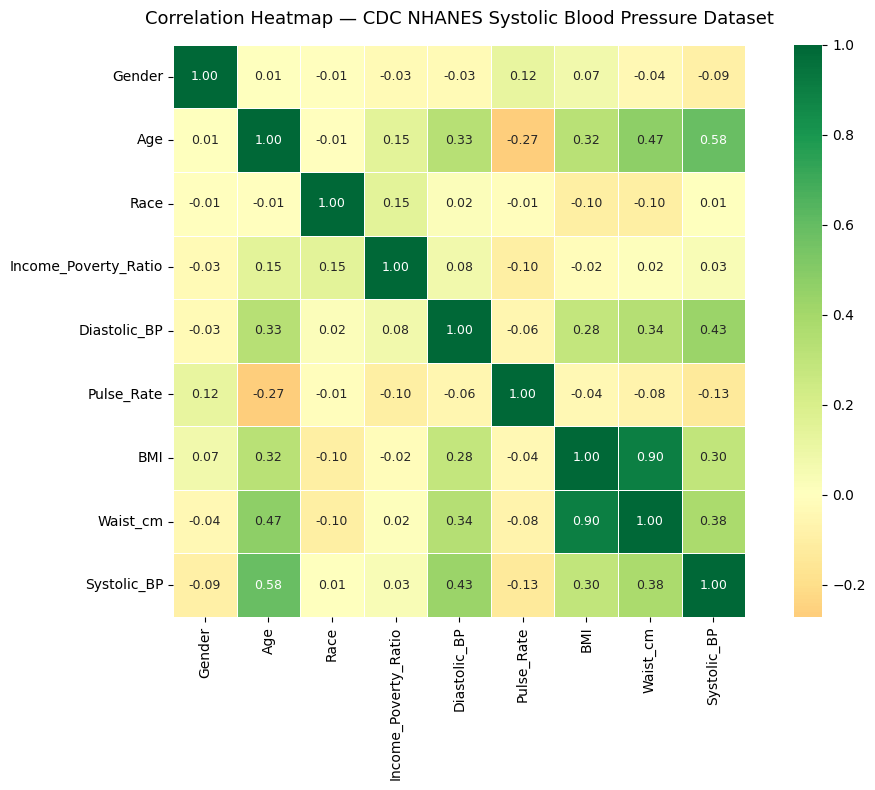

=== TOP CORRELATIONS WITH Systolic_BP ===
Age                     0.585
Diastolic_BP            0.432
Waist_cm                0.381
BMI                     0.298
Pulse_Rate             -0.133
Gender                 -0.094
Income_Poverty_Ratio    0.034
Race                    0.011


In [92]:

# Step 5: Visualization 1 — Correlation Heatmap

df_corr = X.copy()
df_corr['Systolic_BP'] = y.values

plt.figure(figsize=(11, 8))
corr = df_corr.corr()
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, linewidths=0.4, annot_kws={'size': 9}, square=True
)
plt.title('Correlation Heatmap — CDC NHANES Systolic Blood Pressure Dataset',
          fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== TOP CORRELATIONS WITH Systolic_BP ===')
target_corr = corr['Systolic_BP'].drop('Systolic_BP')
print(target_corr.sort_values(key=abs, ascending=False).round(3).to_string())



### Interpretation


---


- Age shows the strongest positive correlation with Systolic BP.
  Arterial stiffness increases naturally with age, raising systolic pressure.
- Diastolic BP shows a meaningful positive correlation.
Both measurements are taken in the same cardiac cycle which is clinically expected.
  
- BMI and Waist circumference show positive correlations.
  Excess body mass increases the heart's workload and cardiac output.
- Pulse Rate shows a mild negative correlation. In this population which includes children and young adults, higher resting heart rates tend to occur in younger, healthier individuals with lower baseline systolic pressure.
- Income-to-poverty ratio shows a mild negative correlation.
  Lower income is linked to higher chronic stress and less preventive care access.
- Gender and Race show weaker correlations but are retained as demographic controls.

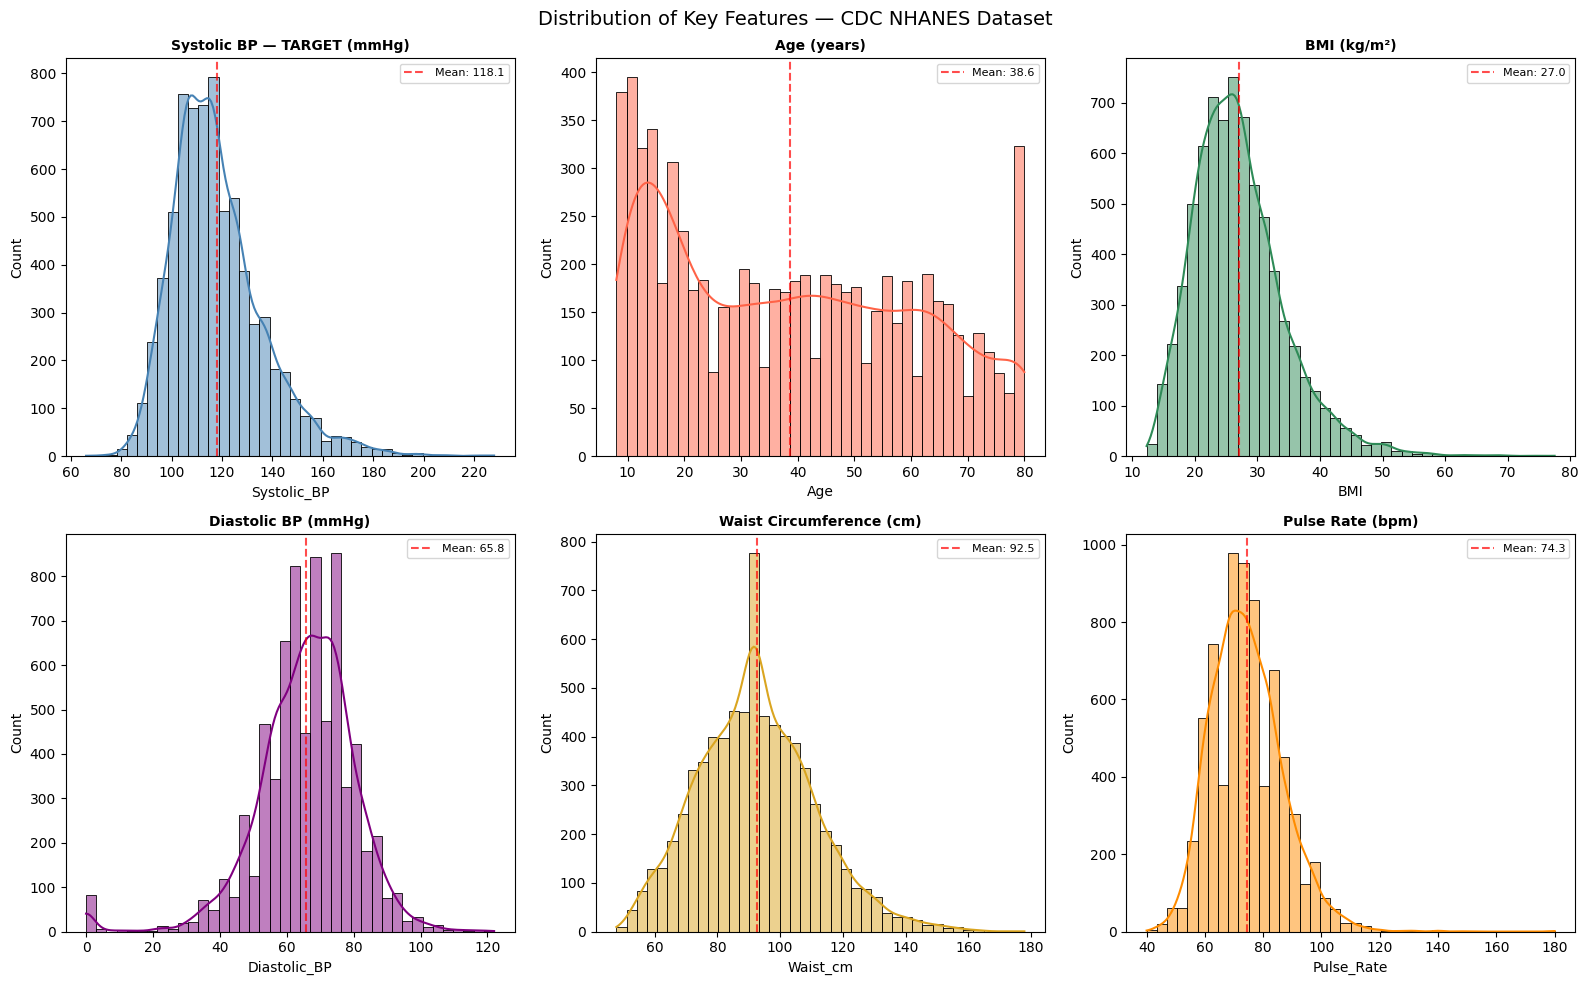

In [93]:
# Step 6: Visualization 2 — Feature Distributions

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribution of Key Features — CDC NHANES Dataset', fontsize=14)

plots = [
    ('Systolic_BP',  'Systolic BP — TARGET (mmHg)',  'steelblue'),
    ('Age',          'Age (years)',                   'tomato'),
    ('BMI',          'BMI (kg/m²)',                   'seagreen'),
    ('Diastolic_BP', 'Diastolic BP (mmHg)',           'purple'),
    ('Waist_cm',     'Waist Circumference (cm)',      'goldenrod'),
    ('Pulse_Rate',   'Pulse Rate (bpm)',               'darkorange'),
]

df_plot = X.copy()
df_plot['Systolic_BP'] = y.values

for ax, (col, label, color) in zip(axes.flatten(), plots):
    sns.histplot(df_plot[col], kde=True, ax=ax, color=color, bins=40)
    ax.set_title(label, fontweight='bold', fontsize=10)
    m = df_plot[col].mean()
    ax.axvline(m, color='red', linestyle='--', alpha=0.7, label=f'Mean: {m:.1f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('distributions.png', dpi=150, bbox_inches='tight')
plt.show()



### Interpretation


---


- Systolic BP: Roughly normal with right skew. Mean ~118 mmHg — many
  participants fall in the elevated or High Stage 1 range.

- Age: Bimodal distribution — a peak in younger population and another in
  older adults (60s-70s), reflecting the CDC survey sampling design.

- BMI: Right-skewed. Most participants are overweight (25-35 BMI) with
  a long tail of obese individuals pulling the distribution right.

- Diastolic BP: Near-normal, centered around 70-75 mmHg.

- Waist circumference: Right-skewed, consistent with the BMI distribution.

- Pulse rate: Roughly normal centered near 70 bpm, the expected resting heart rate.
  These different scales confirm why standardization is mandatory.

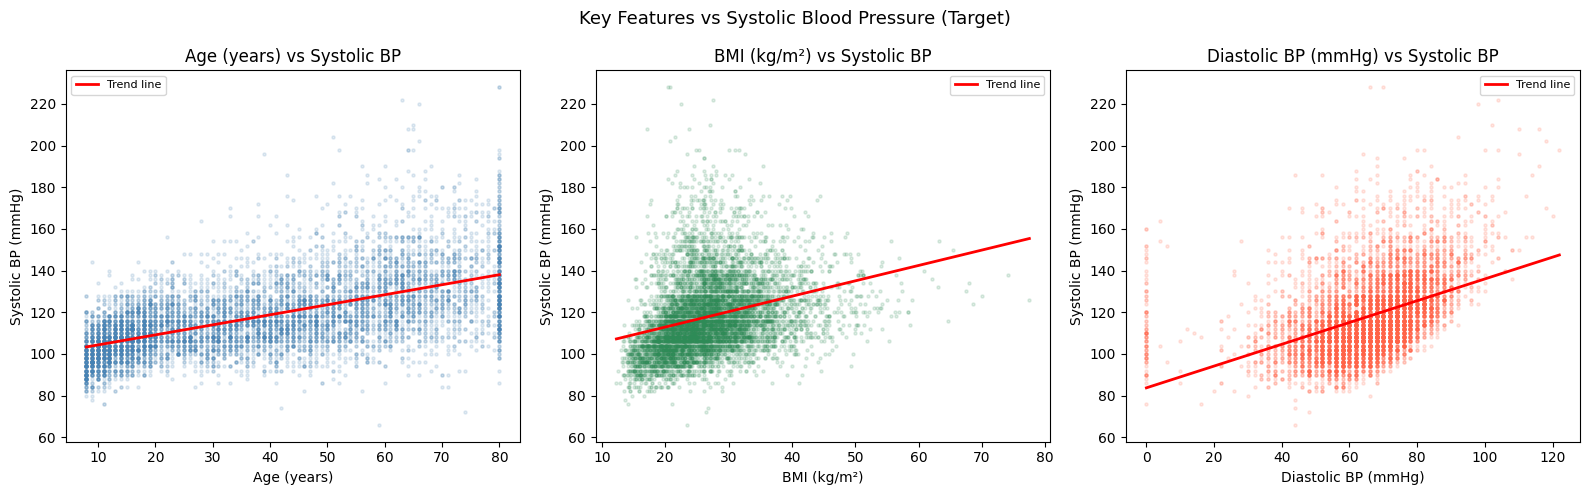

In [94]:
# Step 7: Visualizaion 3 — Scatter Plots vs Target

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Key Features vs Systolic Blood Pressure (Target)', fontsize=13)

scatter_pairs = [
    ('Age',          'Age (years)',           'steelblue'),
    ('BMI',          'BMI (kg/m²)',            'seagreen'),
    ('Diastolic_BP', 'Diastolic BP (mmHg)',   'tomato'),
]

for ax, (col, label, color) in zip(axes, scatter_pairs):
    ax.scatter(X[col], y, alpha=0.15, s=5, color=color)
    z = np.polyfit(X[col], y, 1)
    p = np.poly1d(z)
    xl = np.linspace(X[col].min(), X[col].max(), 100)
    ax.plot(xl, p(xl), 'r-', linewidth=2, label='Trend line')
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel('Systolic BP (mmHg)')
    ax.set_title(f'{label} vs Systolic BP')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('scatter_features_vs_target.png', dpi=150, bbox_inches='tight')
plt.show()

Standardization is necessary because:
- Age ranges 0-80, Waist ranges 50-200, Income ratio ranges 0-5.
- Without scaling, large-value features dominate gradient descent updates.
- StandardScaler transforms every feature to mean=0, std=1.

In [95]:
# Step 8: Standardize + Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit + transform on train
X_test_scaled  = scaler.transform(X_test)        # transform only on test

print(f'Training samples: {len(X_train):,}')
print(f'Testing samples:  {len(X_test):,}')
print('Standardization complete — no data leakage.')
print(f'Train feature means after scaling (should be ~0): {X_train_scaled.mean(axis=0).round(3)}')

Training samples: 5,737
Testing samples:  1,435
Standardization complete — no data leakage.
Train feature means after scaling (should be ~0): [ 0.  0.  0.  0.  0. -0. -0.  0.]


For linear regression warm_start=True and max_iter=1 is used so as to enable manual looping and record MSE at every epoch, this gives  the loss curve data.
eta0=0.001 is the learning rate. Lower = slower but more stable.

In [96]:
# Model 1: Linear Regression with Gradient Descent (SGDRegressor)

print('Training Linear Regression with Gradient Descent...')

train_losses, test_losses = [], []

lr_model = SGDRegressor(
    max_iter=1,
    warm_start=True,
    learning_rate='constant',
    eta0=0.001,
    random_state=42,
    tol=None
)

EPOCHS = 300

for epoch in range(EPOCHS):
    lr_model.fit(X_train_scaled, y_train)
    train_losses.append(mean_squared_error(y_train, lr_model.predict(X_train_scaled)))
    test_losses.append(mean_squared_error(y_test,  lr_model.predict(X_test_scaled)))

lr_preds = lr_model.predict(X_test_scaled)
lr_mse   = mean_squared_error(y_test, lr_preds)
lr_rmse  = np.sqrt(lr_mse)
lr_r2    = r2_score(y_test, lr_preds)

print(f'Linear Regression -> MSE: {lr_mse:.2f} | RMSE: {lr_rmse:.2f} mmHg | R²: {lr_r2:.4f}')

Training Linear Regression with Gradient Descent...
Linear Regression -> MSE: 192.13 | RMSE: 13.86 mmHg | R²: 0.3809


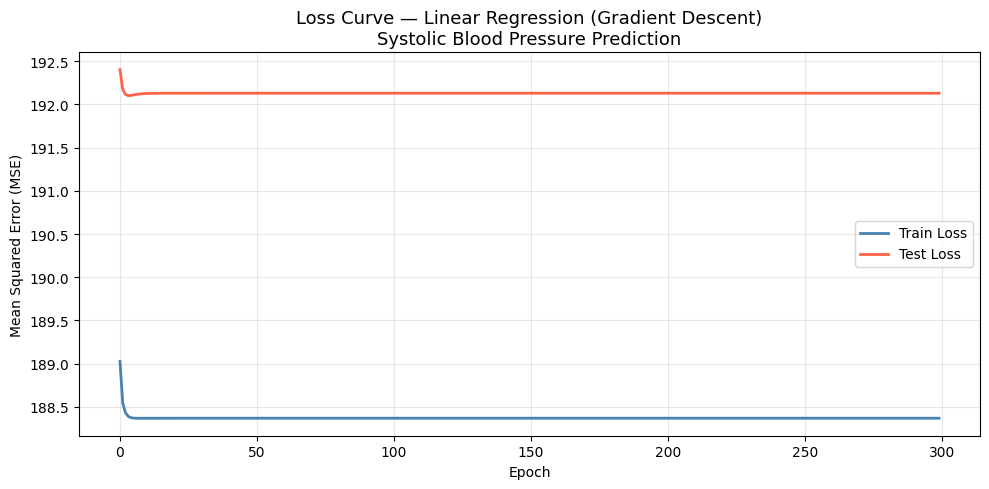


Final RMSE: 13.9 mmHg 



In [97]:

# Loss curve — Linear Regression

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', color='steelblue', linewidth=2)
plt.plot(test_losses,  label='Test Loss',  color='tomato',    linewidth=2)
plt.title('Loss Curve — Linear Regression (Gradient Descent)\nSystolic Blood Pressure Prediction', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('loss_curve_lr.png', dpi=150)
plt.show()

print(f'''
Final RMSE: {lr_rmse:.1f} mmHg
''')

### Loss curve interpretation


---


- Both train and test loss drop sharply in the first ~50 epochs then plateau.
- This indicates the model has converged, further training yields no improvement.
- Train and test loss remain close together, no significant overfitting.
- Final RMSE: 13.9 mmHg average prediction error.

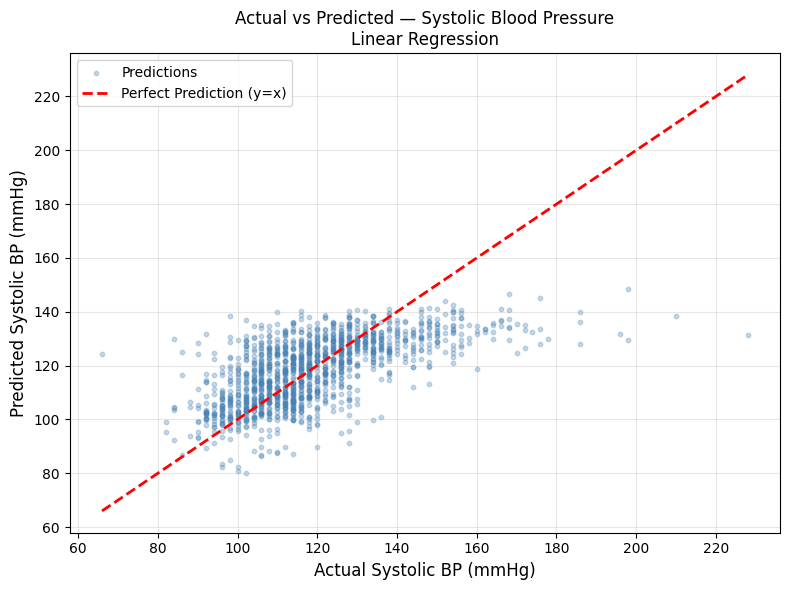

In [98]:

# Scatter Plot — Actual vs Predicted (Linear Regression)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, lr_preds, alpha=0.3, color='steelblue', s=10, label='Predictions')
min_v = min(y_test.min(), lr_preds.min())
max_v = max(y_test.max(), lr_preds.max())
plt.plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=2, label='Perfect Prediction (y=x)')
plt.xlabel('Actual Systolic BP (mmHg)', fontsize=12)
plt.ylabel('Predicted Systolic BP (mmHg)', fontsize=12)
plt.title('Actual vs Predicted — Systolic Blood Pressure\nLinear Regression', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('scatter_actual_vs_predicted.png', dpi=150)
plt.show()



### Interpretation


---


- Points close to the red dashed diagonal line = accurate predictions.
The model performs best in the 110-150 mmHg range where most patients fall.
- Larger spread at very high values (>180 mmHg) is expected as fewer training
examples exist at extremes and hypertensive crises involve unmeasured factors.

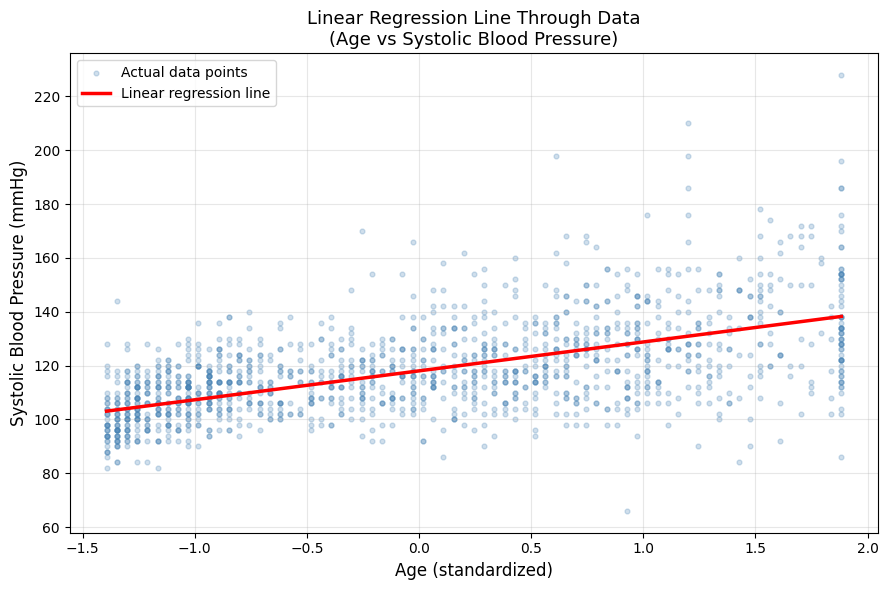

In [99]:
# Scatter Plot — Linear Regression Line Through Data

# Shows the fitted linear regression line passing through scattered data.
# Uses Age vs Systolic BP which is the clearest demographic predictor.

age_idx = list(X.columns).index('Age')
X_age_train = X_train_scaled[:, age_idx].reshape(-1, 1)
X_age_test  = X_test_scaled[:, age_idx].reshape(-1, 1)

viz_lr = LinearRegression()
viz_lr.fit(X_age_train, y_train)

x_line = np.linspace(X_age_test.min(), X_age_test.max(), 200).reshape(-1, 1)
y_line = viz_lr.predict(x_line)

plt.figure(figsize=(9, 6))
plt.scatter(X_age_test, y_test, alpha=0.25, s=12,
            color='steelblue', label='Actual data points')
plt.plot(x_line, y_line, color='red', linewidth=2.5,
         label='Linear regression line')
plt.xlabel('Age (standardized)', fontsize=12)
plt.ylabel('Systolic Blood Pressure (mmHg)', fontsize=12)
plt.title('Linear Regression Line Through Data\n(Age vs Systolic Blood Pressure)', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('scatter_linear_fit.png', dpi=150)
plt.show()

In [100]:
# Model 2: Decision Tree

# max_depth=8 prevents overfitting
# min_samples_split and min_samples_leaf add further regularisation.

print('Training Decision Tree...')
dt_model = DecisionTreeRegressor(
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)
dt_model.fit(X_train_scaled, y_train)
dt_preds = dt_model.predict(X_test_scaled)
dt_mse   = mean_squared_error(y_test, dt_preds)
dt_rmse  = np.sqrt(dt_mse)
dt_r2    = r2_score(y_test, dt_preds)
print(f'Decision Tree  -> MSE: {dt_mse:.2f} | RMSE: {dt_rmse:.2f} mmHg | R²: {dt_r2:.4f}')

Training Decision Tree...
Decision Tree  -> MSE: 173.88 | RMSE: 13.19 mmHg | R²: 0.4397


In [101]:
# Model 3: Random Forest

# 200 trees trained on random bootstrap samples of the data.
# Each tree sees only sqrt(n_features) at each split, reduces correlation between trees.
# Ensemble averaging reduces variance vs a single decision tree.

print('Training Random Forest...')
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_test_scaled)
rf_mse   = mean_squared_error(y_test, rf_preds)
rf_rmse  = np.sqrt(rf_mse)
rf_r2    = r2_score(y_test, rf_preds)
print(f'Random Forest  -> MSE: {rf_mse:.2f} | RMSE: {rf_rmse:.2f} mmHg | R²: {rf_r2:.4f}')

Training Random Forest...
Random Forest  -> MSE: 157.86 | RMSE: 12.56 mmHg | R²: 0.4913


Model                         MSE     RMSE       R2
------------------------------------------------------------
Linear Regression          192.13    13.86   0.3809
Decision Tree              173.88    13.19   0.4397
Random Forest              157.86    12.56   0.4913


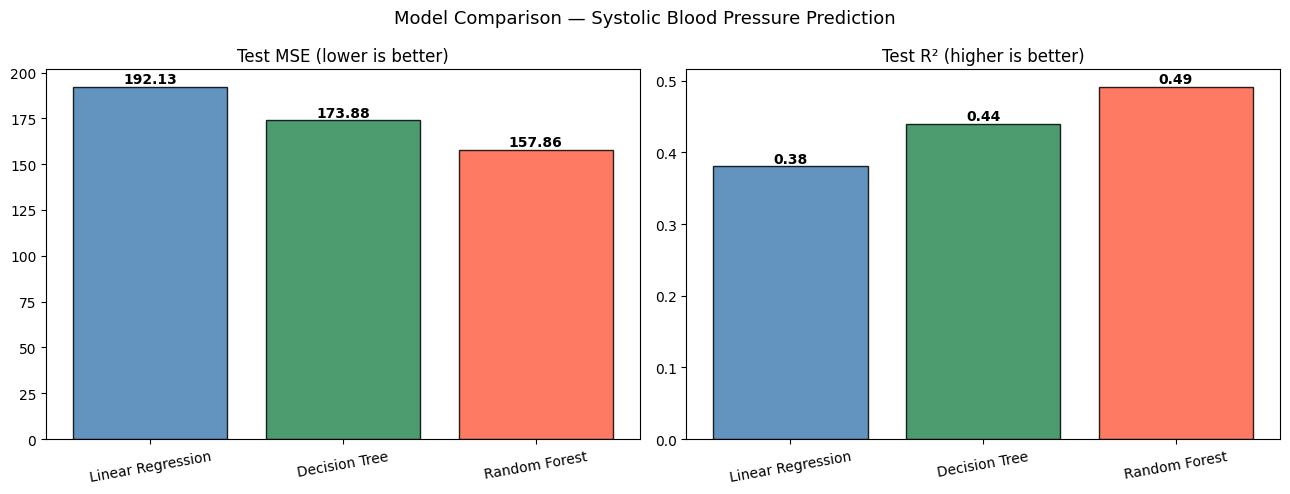

In [102]:
# Model Comparison

print('='*60)
print(f'{"Model":<22} {"MSE":>10} {"RMSE":>8} {"R2":>8}')
print('-'*60)
print(f'{"Linear Regression":<22} {lr_mse:>10.2f} {lr_rmse:>8.2f} {lr_r2:>8.4f}')
print(f'{"Decision Tree":<22} {dt_mse:>10.2f} {dt_rmse:>8.2f} {dt_r2:>8.4f}')
print(f'{"Random Forest":<22} {rf_mse:>10.2f} {rf_rmse:>8.2f} {rf_r2:>8.4f}')
print('='*60)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
names  = ['Linear Regression', 'Decision Tree', 'Random Forest']
colors = ['steelblue', 'seagreen', 'tomato']

for ax, vals, title in zip(
    axes,
    [[lr_mse, dt_mse, rf_mse], [lr_r2, dt_r2, rf_r2]],
    ['Test MSE (lower is better)', 'Test R² (higher is better)']
):
    bars = ax.bar(names, vals, color=colors, edgecolor='black', alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals)*0.01,
                f'{v:.2f}', ha='center', fontweight='bold', fontsize=10)
    ax.set_title(title, fontsize=12)
    ax.tick_params(axis='x', rotation=10)

plt.suptitle('Model Comparison — Systolic Blood Pressure Prediction', fontsize=13)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

In [103]:
# Saving the best model

all_models = {
    'Linear Regression': (lr_mse, lr_model),
    'Decision Tree':     (dt_mse, dt_model),
    'Random Forest':     (rf_mse, rf_model),
}

best_name  = min(all_models, key=lambda k: all_models[k][0])
best_model = all_models[best_name][1]
best_mse   = all_models[best_name][0]

print(f'Best Model: {best_name}')
print(f'  MSE:  {best_mse:.2f}')
print(f'  RMSE: {np.sqrt(best_mse):.2f} mmHg average prediction error')

joblib.dump(best_model,         'best_model.pkl')
joblib.dump(scaler,             'scaler.pkl')
joblib.dump(X.columns.tolist(), 'feature_names.pkl')

print('\nSaved to linear_regression/ folder:')
print('  best_model.pkl')
print('  scaler.pkl')
print('  feature_names.pkl')

Best Model: Random Forest
  MSE:  157.86
  RMSE: 12.56 mmHg average prediction error

Saved to linear_regression/ folder:
  best_model.pkl
  scaler.pkl
  feature_names.pkl


In [104]:
# Sample prediction — one data point from test set

sample     = X_test_scaled[0].reshape(1, -1)
prediction = best_model.predict(sample)
actual     = y_test.iloc[0]

print('=== SAMPLE PREDICTION ===')
print(f'Predicted Systolic BP: {prediction[0]:.1f} mmHg')
print(f'Actual Systolic BP:    {actual:.1f} mmHg')
print(f'Error:                 {abs(prediction[0] - actual):.1f} mmHg')

pred_val = prediction[0]
if pred_val < 120:
    category = 'Normal (< 120 mmHg)'
elif pred_val < 130:
    category = 'Elevated (120-129 mmHg)'
elif pred_val < 140:
    category = 'High Stage 1 (130-139 mmHg)'
else:
    category = 'High Stage 2 (>= 140 mmHg)'

print(f'\nRisk Category: {category}')


=== SAMPLE PREDICTION ===
Predicted Systolic BP: 103.9 mmHg
Actual Systolic BP:    112.0 mmHg
Error:                 8.1 mmHg

Risk Category: Normal (< 120 mmHg)
